https://chem.libretexts.org/Ancillary_Materials/Interactive_Applications/Jupyter_Notebooks/Quantum_Harmonic_Oscillators_-_Plotting_Eigenstates_(Python_Notebook)

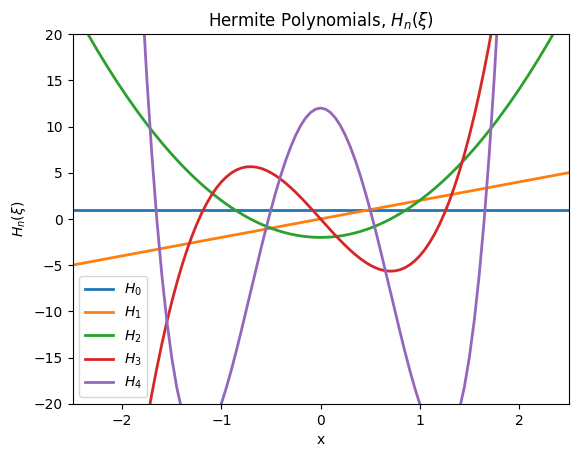

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy.polynomial.hermite as Herm

#Choose simple units
m=1.
w=1.
hbar=1.

#Discretized space
dx = 0.05
x_lim = 12
x = numpy.arange(-x_lim,x_lim,dx)

def hermite(x, n):
    xi = numpy.sqrt(m*w/hbar)*x
    herm_coeffs = numpy.zeros(n+1)
    herm_coeffs[n] = 1
    return Herm.hermval(xi, herm_coeffs)

plt.figure()
plt.plot(x, hermite(x,0), linewidth=2,label=r"$H_0$")
plt.plot(x, hermite(x,1), linewidth=2,label=r"$H_1$")
plt.plot(x, hermite(x,2), linewidth=2,label=r"$H_2$")
plt.plot(x, hermite(x,3), linewidth=2,label=r"$H_3$")
plt.plot(x, hermite(x,4), linewidth=2,label=r"$H_4$")

#Set limits for axes
plt.xlim([-2.5,2.5])
plt.ylim([-20,20])

#Set axes labels
plt.xlabel("x")
plt.ylabel(r"$H_n(\xi)$")
plt.title(r"Hermite Polynomials, $H_n(\xi)$")
plt.legend()
plt.show()

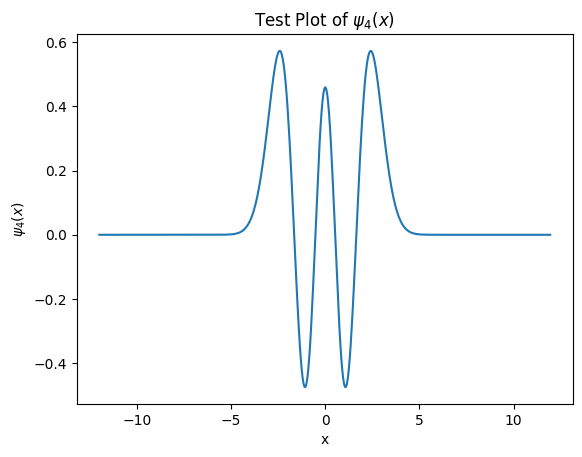

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy.polynomial.hermite as Herm
import math

#Choose simple units
m=1.
w=1.
hbar=1.
#Discretized space
dx = 0.05
x_lim = 12
x = numpy.arange(-x_lim,x_lim,dx)

def hermite(x, n):
    xi = numpy.sqrt(m*w/hbar)*x
    herm_coeffs = numpy.zeros(n+1)
    herm_coeffs[n] = 1
    return Herm.hermval(xi, herm_coeffs)

def stationary_state(x,n):
    xi = numpy.sqrt(m*w/hbar)*x
    prefactor = 1./math.sqrt(2.**n * math.factorial(n)) * (m*w/(numpy.pi*hbar))**(0.25)
    psi = prefactor * numpy.exp(- xi**2 / 2) * hermite(x,n)
    return psi

plt.figure()
plt.plot(x, stationary_state(x,4))
plt.xlabel(r"x")
plt.ylabel(r"$\psi_4(x)$")
plt.title(r"Test Plot of $\psi_4(x)$")
plt.show()

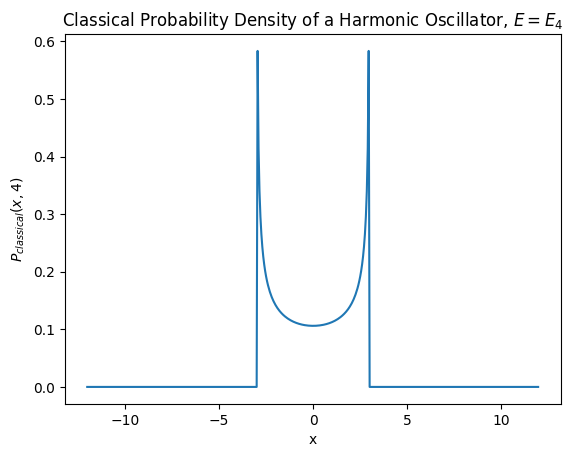

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy.polynomial.hermite as Herm

#Choose simple units
m=1.
w=1.
hbar=1.
#Discretized space
dx = 0.05
x_lim = 12
x = numpy.arange(-x_lim,x_lim,dx)

def classical_P(x,n):
    E = hbar*w*(n+0.5)
    x_max = numpy.sqrt(2*E/(m*w**2))
    classical_prob = numpy.zeros(x.shape[0])
    x_inside = abs(x) < (x_max - 0.025)
    classical_prob[x_inside] = 1./numpy.pi/numpy.sqrt(x_max**2-x[x_inside]*x[x_inside])
    return classical_prob

plt.figure()
plt.plot(x, classical_P(x,4))
plt.xlabel(r"x")
plt.ylabel(r"$P_{classical}(x,4)$")
plt.title(r"Classical Probability Density of a Harmonic Oscillator, $E=E_4$")
plt.show()

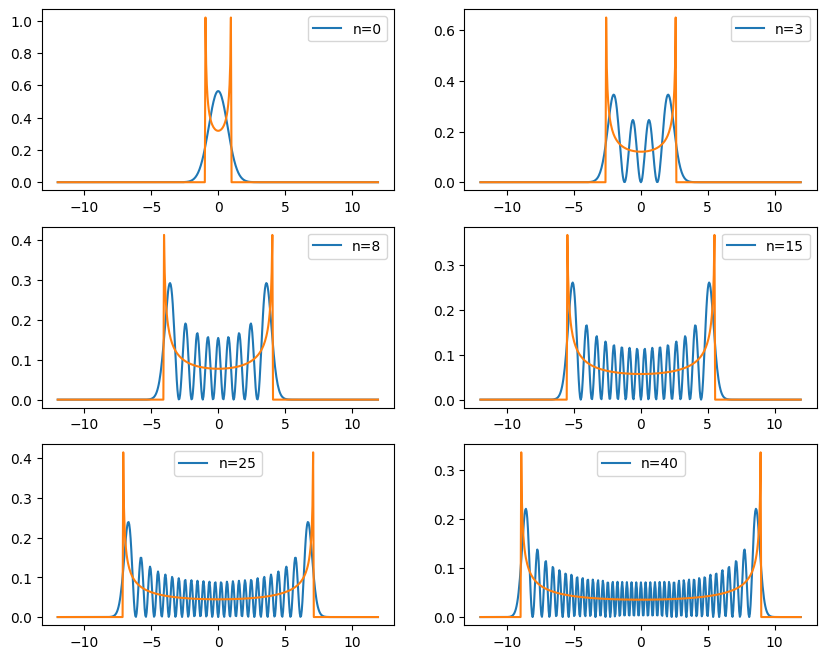

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy.polynomial.hermite as Herm
import math

#Choose simple units
m=1.
w=1.
hbar=1.
#Discretized space
dx = 0.05
x_lim = 12
x = numpy.arange(-x_lim,x_lim,dx)

def hermite(x, n):
    xi = numpy.sqrt(m*w/hbar)*x
    herm_coeffs = numpy.zeros(n+1)
    herm_coeffs[n] = 1
    return Herm.hermval(xi, herm_coeffs)
def stationary_state(x,n):
    xi = numpy.sqrt(m*w/hbar)*x
    prefactor = 1./math.sqrt(2.**n * math.factorial(n)) * (m*w/(numpy.pi*hbar))**(0.25)
    psi = prefactor * numpy.exp(- xi**2 / 2) * hermite(x,n)
    return psi

def classical_P(x,n):
    E = hbar*w*(n+0.5)
    x_max = numpy.sqrt(2*E/(m*w**2))
    classical_prob = numpy.zeros(x.shape[0])
    x_inside = abs(x) < (x_max - 0.025)
    classical_prob[x_inside] = 1./numpy.pi/numpy.sqrt(x_max**2-x[x_inside]*x[x_inside])
    return classical_prob

plt.figure(figsize=(10, 8))
plt.subplot(3,2,1)
plt.plot(x, numpy.conjugate(stationary_state(x,0))*stationary_state(x,0), label="n=0")
plt.plot(x, classical_P(x,0))
plt.legend()
plt.subplot(3,2,2)
plt.plot(x, numpy.conjugate(stationary_state(x,3))*stationary_state(x,3), label="n=3")
plt.plot(x, classical_P(x,3))
plt.legend()
plt.subplot(3,2,3)
plt.plot(x, numpy.conjugate(stationary_state(x,8))*stationary_state(x,8), label="n=8")
plt.plot(x, classical_P(x,8))
plt.legend()
plt.subplot(3,2,4)
plt.plot(x, numpy.conjugate(stationary_state(x,15))*stationary_state(x,15), label="n=15")
plt.plot(x, classical_P(x,15))
plt.legend()
plt.subplot(3,2,5)
plt.plot(x, numpy.conjugate(stationary_state(x,25))*stationary_state(x,25), label="n=25")
plt.plot(x, classical_P(x,25))
plt.legend()
plt.subplot(3,2,6)
plt.plot(x, numpy.conjugate(stationary_state(x,40))*stationary_state(x,40), label="n=40")
plt.plot(x, classical_P(x,40))
plt.legend()
plt.show()

Quantum Harmonic Oscillator: Automated Dynamics Explorer
--- Generating Standard Derivation Sweep: Correspondence Principle ---


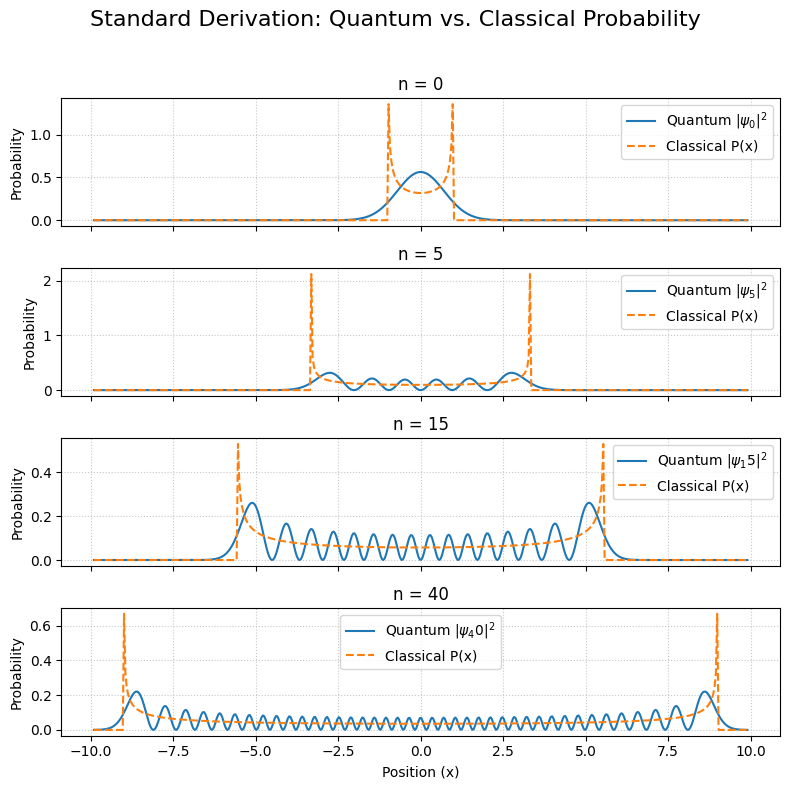


--- Generating SQC Dynamic Sweep: Coherent State Evolution ---


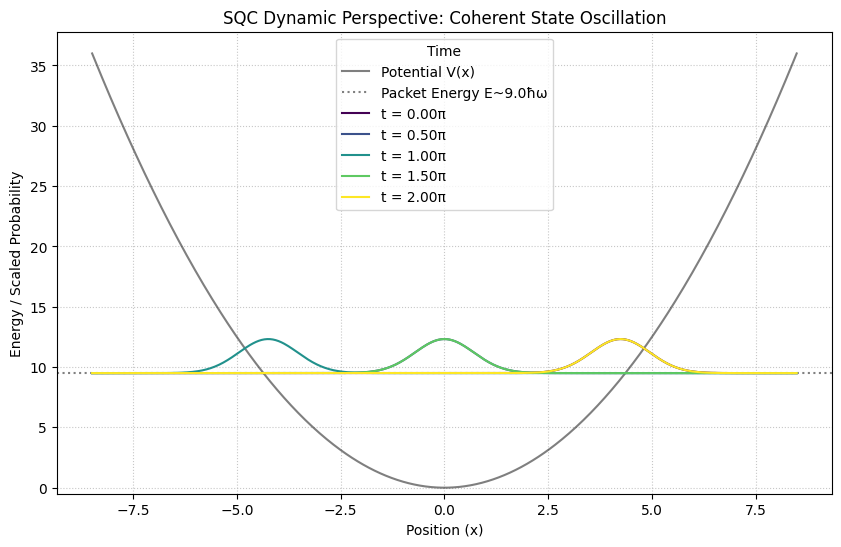

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.polynomial.hermite as Herm
import math
import warnings

# Ignore common warnings
warnings.filterwarnings('ignore')

#======================================================================
# PART 1: CORE CALCULATION FUNCTIONS (from source notebook)
#======================================================================

# Using simple units where m, w, hbar are 1 for clarity
M = 1.
W = 1.
H_BAR = 1.

def stationary_state(x, n):
    """
    Calculates the normalized stationary state (eigenfunction) psi_n(x).
    """
    xi = np.sqrt(M * W / H_BAR) * x
    herm_coeffs = np.zeros(n + 1)
    herm_coeffs[n] = 1
    hermite_poly = Herm.hermval(xi, herm_coeffs)

    prefactor = 1. / math.sqrt(2.**n * math.factorial(n)) * (M * W / (np.pi * H_BAR))**(0.25)
    psi = prefactor * np.exp(-xi**2 / 2) * hermite_poly
    return psi

def classical_prob_density(x, n):
    """
    Calculates the classical probability density for a particle with energy E_n.
    """
    E = H_BAR * W * (n + 0.5)
    x_max = np.sqrt(2 * E / (M * W**2))

    classical_prob = np.zeros(x.shape[0])
    # Find points within the classical turning points
    x_inside = np.abs(x) < x_max

    # Calculate probability for those points
    classical_prob[x_inside] = 1. / np.pi / np.sqrt(x_max**2 - x[x_inside]**2)
    return classical_prob

def potential_well(x):
    """Calculates the parabolic potential V(x)."""
    return 0.5 * M * W**2 * x**2

#======================================================================
# PART 2: STANDARD SIMULATION - CORRESPONDENCE PRINCIPLE
#======================================================================

def plot_qho_correspondence_sweep(n_values):
    """
    Plots quantum vs classical probability for different quantum numbers n
    to illustrate the correspondence principle.
    """
    print("--- Generating Standard Derivation Sweep: Correspondence Principle ---")

    num_plots = len(n_values)
    fig, axes = plt.subplots(num_plots, 1, figsize=(8, 2 * num_plots), sharex=True)
    fig.suptitle('Standard Derivation: Quantum vs. Classical Probability', fontsize=16)

    x_lim = np.sqrt(2 * H_BAR * W * (n_values[-1] + 0.5) / (M * W**2)) * 1.1
    x = np.linspace(-x_lim, x_lim, 500)

    for i, n in enumerate(n_values):
        ax = axes[i]
        quantum_pd = np.abs(stationary_state(x, n))**2
        classical_pd = classical_prob_density(x, n)

        ax.plot(x, quantum_pd, label=f'Quantum $|\psi_{n}|^2$')
        ax.plot(x, classical_pd, label='Classical P(x)', linestyle='--')
        ax.set_ylabel('Probability')
        ax.legend()
        ax.set_title(f'n = {n}')
        ax.grid(True, linestyle=':', alpha=0.7)

    axes[-1].set_xlabel('Position (x)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#======================================================================
# PART 3: SQC SIMULATION - COHERENT STATE DYNAMICS
#======================================================================

def construct_coherent_state(x, n_max, alpha):
    """
    Constructs the wavefunction of a coherent state |alpha> by summing
    eigenstates |n>.

    *** THIS FUNCTION HAS BEEN CORRECTED. ***
    """
    psi_coherent = np.zeros_like(x, dtype=complex)
    for n in range(n_max):
        # --- FIX: Replaced np.sqrt with math.sqrt to handle integer argument ---
        coeff = alpha**n / math.sqrt(math.factorial(n))
        psi_coherent += coeff * stationary_state(x, n)

    # Add normalization factor exp(-|alpha|^2 / 2)
    psi_coherent *= np.exp(-0.5 * np.abs(alpha)**2)
    return psi_coherent

def plot_coherent_state_evolution(alpha0, time_points, n_sum_max=40):
    """
    Shows the time evolution of a coherent state's probability distribution
    oscillating within the potential well.
    """
    print("\n--- Generating SQC Dynamic Sweep: Coherent State Evolution ---")

    x_lim = (np.abs(alpha0) + 3) * np.sqrt(2 * H_BAR / (M * W))
    x = np.linspace(-x_lim, x_lim, 500)

    plt.figure(figsize=(10, 6))
    plt.title('SQC Dynamic Perspective: Coherent State Oscillation')

    # Plot the potential well in the background
    V = potential_well(x)
    E_packet = H_BAR * W * (np.abs(alpha0)**2 + 0.5)
    plt.plot(x, V, 'k-', label='Potential V(x)', alpha=0.5)
    plt.axhline(E_packet, color='gray', linestyle=':', label=f'Packet Energy E~{alpha0**2:.1f}ħω')

    colors = plt.cm.viridis(np.linspace(0, 1, len(time_points)))

    for i, t in enumerate(time_points):
        # Evolve alpha in time
        alpha_t = alpha0 * np.exp(-1j * W * t)

        # Construct the wavefunction at time t
        psi_t = construct_coherent_state(x, n_sum_max, alpha_t)

        # Get the probability density and scale it for visualization
        prob_t = np.abs(psi_t)**2

        # We add the energy of the packet to plot it at the right height in the well
        plt.plot(x, prob_t * 5 + E_packet, color=colors[i], label=f't = {t/np.pi:.2f}π')

    plt.xlabel('Position (x)')
    plt.ylabel('Energy / Scaled Probability')
    plt.legend(title="Time")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=-0.5)
    plt.show()

#======================================================================
# MAIN EXECUTION BLOCK
#======================================================================

if __name__ == "__main__":
    print("Quantum Harmonic Oscillator: Automated Dynamics Explorer")
    print("="*60)

    # --- Standard Simulation Sweep ---
    # Show the correspondence principle for low, medium, and high n
    plot_qho_correspondence_sweep(n_values=[0, 5, 15, 40])

    # --- SQC Dynamic Simulation Sweep ---
    # Show a coherent state oscillating. The classical period is 2*pi.
    # We will choose an initial alpha corresponding to a starting position.
    alpha_initial = 3.0
    # Choose time steps that cover one full oscillation
    oscillation_times = np.linspace(0, 2 * np.pi, 5)

    plot_coherent_state_evolution(alpha_initial, oscillation_times)

Quantum Harmonic Oscillator: Automated Dynamics Explorer
--- Generating Standard Derivation Sweep: Correspondence Principle ---


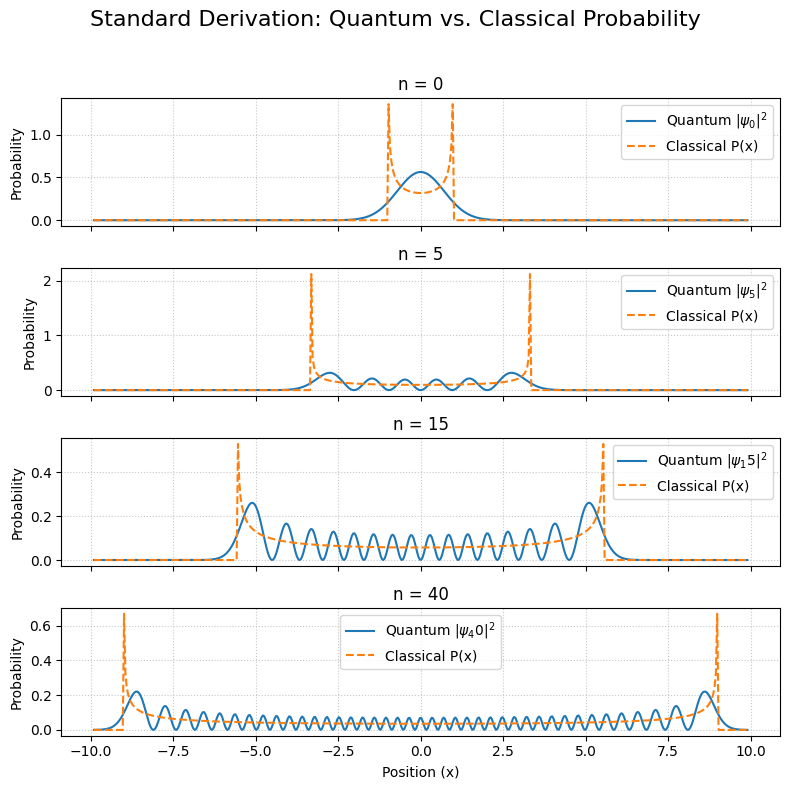


--- Generating SQC Dynamic Sweep: Coherent State Oscillation ---


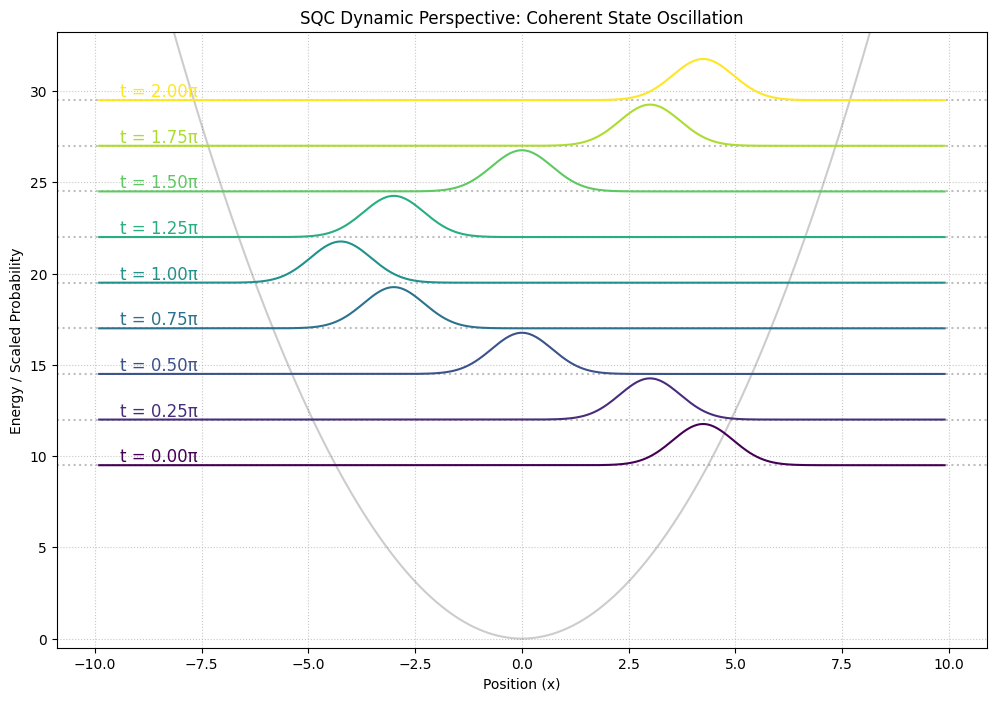

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.polynomial.hermite as Herm
import math
import warnings

# Ignore common warnings
warnings.filterwarnings('ignore')

#======================================================================
# PART 1: CORE CALCULATION FUNCTIONS (from source notebook)
#======================================================================

# Using simple units where m, w, hbar are 1 for clarity
M = 1.
W = 1.
H_BAR = 1.

def stationary_state(x, n):
    """
    Calculates the normalized stationary state (eigenfunction) psi_n(x).
    """
    xi = np.sqrt(M * W / H_BAR) * x
    herm_coeffs = np.zeros(n + 1)
    herm_coeffs[n] = 1
    hermite_poly = Herm.hermval(xi, herm_coeffs)

    prefactor = 1. / math.sqrt(2.**n * math.factorial(n)) * (M * W / (np.pi * H_BAR))**(0.25)
    psi = prefactor * np.exp(-xi**2 / 2) * hermite_poly
    return psi

def classical_prob_density(x, n):
    """
    Calculates the classical probability density for a particle with energy E_n.
    """
    E = H_BAR * W * (n + 0.5)
    x_max = np.sqrt(2 * E / (M * W**2))

    classical_prob = np.zeros(x.shape[0])
    # Find points within the classical turning points
    x_inside = np.abs(x) < x_max

    # Calculate probability for those points
    classical_prob[x_inside] = 1. / np.pi / np.sqrt(x_max**2 - x[x_inside]**2)
    return classical_prob

def potential_well(x):
    """Calculates the parabolic potential V(x)."""
    return 0.5 * M * W**2 * x**2

#======================================================================
# PART 2: STANDARD SIMULATION - CORRESPONDENCE PRINCIPLE
#======================================================================

def plot_qho_correspondence_sweep(n_values):
    """
    Plots quantum vs classical probability for different quantum numbers n
    to illustrate the correspondence principle.
    """
    print("--- Generating Standard Derivation Sweep: Correspondence Principle ---")

    num_plots = len(n_values)
    fig, axes = plt.subplots(num_plots, 1, figsize=(8, 2 * num_plots), sharex=True)
    fig.suptitle('Standard Derivation: Quantum vs. Classical Probability', fontsize=16)

    x_lim = np.sqrt(2 * H_BAR * W * (n_values[-1] + 0.5) / (M * W**2)) * 1.1
    x = np.linspace(-x_lim, x_lim, 500)

    for i, n in enumerate(n_values):
        ax = axes[i]
        quantum_pd = np.abs(stationary_state(x, n))**2
        classical_pd = classical_prob_density(x, n)

        ax.plot(x, quantum_pd, label=f'Quantum $|\psi_{n}|^2$')
        ax.plot(x, classical_pd, label='Classical P(x)', linestyle='--')
        ax.set_ylabel('Probability')
        ax.legend()
        ax.set_title(f'n = {n}')
        ax.grid(True, linestyle=':', alpha=0.7)

    axes[-1].set_xlabel('Position (x)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#======================================================================
# PART 3: SQC SIMULATION - COHERENT STATE DYNAMICS
#======================================================================

def construct_coherent_state(x, n_max, alpha):
    """
    Constructs the wavefunction of a coherent state |alpha> by summing
    eigenstates |n>.
    """
    psi_coherent = np.zeros_like(x, dtype=complex)
    for n in range(n_max):
        coeff = alpha**n / math.sqrt(math.factorial(n))
        psi_coherent += coeff * stationary_state(x, n)

    # Add normalization factor exp(-|alpha|^2 / 2)
    psi_coherent *= np.exp(-0.5 * np.abs(alpha)**2)
    return psi_coherent

def plot_coherent_state_evolution(alpha0, time_points, n_sum_max=40):
    """
    Shows the time evolution of a coherent state's probability distribution
    oscillating within the potential well.

    *** THIS FUNCTION HAS BEEN CORRECTED FOR BETTER VISUALIZATION. ***
    """
    print("\n--- Generating SQC Dynamic Sweep: Coherent State Oscillation ---")

    x_lim = (np.abs(alpha0) + 4) * np.sqrt(2 * H_BAR / (M * W))
    x = np.linspace(-x_lim, x_lim, 500)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_title('SQC Dynamic Perspective: Coherent State Oscillation')

    # Plot the potential well in the background
    V = potential_well(x)
    E_packet = H_BAR * W * (np.abs(alpha0)**2 + 0.5)
    ax.plot(x, V, 'k-', label='Potential V(x)', alpha=0.2)

    # --- New visualization parameters ---
    PROB_SCALING = 4.0      # To make the peaks visually larger
    VERTICAL_OFFSET = 2.5   # To separate the time steps vertically

    colors = plt.cm.viridis(np.linspace(0, 1, len(time_points)))

    for i, t in enumerate(time_points):
        # Evolve alpha in time
        alpha_t = alpha0 * np.exp(-1j * W * t)

        # Construct the wavefunction at time t
        psi_t = construct_coherent_state(x, n_sum_max, alpha_t)

        # Get the probability density
        prob_t = np.abs(psi_t)**2

        # --- New plotting logic with vertical offset ---
        # Each time step is plotted on its own horizontal line
        y_level = E_packet + i * VERTICAL_OFFSET
        ax.axhline(y_level, color='gray', linestyle=':', alpha=0.5)
        ax.plot(x, prob_t * PROB_SCALING + y_level, color=colors[i])

        # Add text label for the time
        ax.text(-x_lim * 0.95, y_level + 0.2, f't = {t/np.pi:.2f}π', color=colors[i], fontsize=12)

    ax.set_xlabel('Position (x)')
    ax.set_ylabel('Energy / Scaled Probability')
    ax.grid(True, linestyle=':', alpha=0.7)
    # Adjust ylim to see all plots clearly
    ax.set_ylim(bottom=-0.5, top=y_level + VERTICAL_OFFSET * 1.5)
    ax.get_yaxis().set_ticks(np.arange(0, y_level + 1, 5))

    plt.show()

#======================================================================
# MAIN EXECUTION BLOCK
#======================================================================

if __name__ == "__main__":
    print("Quantum Harmonic Oscillator: Automated Dynamics Explorer")
    print("="*60)

    # --- Standard Simulation Sweep ---
    # Show the correspondence principle for low, medium, and high n
    plot_qho_correspondence_sweep(n_values=[0, 5, 15, 40])

    # --- SQC Dynamic Simulation Sweep ---
    # Show a coherent state oscillating. The classical period is 2*pi.
    # We will choose an initial alpha corresponding to a starting position.
    alpha_initial = 3.0
    # Choose more time steps to better visualize the oscillation
    oscillation_times = np.linspace(0, 2 * np.pi, 9)

    plot_coherent_state_evolution(alpha_initial, oscillation_times)